In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, f1_score, roc_auc_score

In [83]:
DATA = '../data/'

In [84]:
elo_featured = pd.read_parquet(DATA+'elo_featured.parquet')
display(elo_featured.head())

,global_rank,rating,rank_max,rating_max,rank_avg,rating_avg,rank_min,rating_min,rank_3m_change,rating_3m_change,...,rank_change,rating_change,team_name,year_applied,matches_total_year,wins_year,losses_year,draws_year,goals_for_year,goals_against_year
4372,110,1302,110,1302,110,1302,110,1302,0.0,0.0,...,0.0,0.0,Aden,1962,1.0,1.0,0.0,0.0,4.0,2.0
4527,110,1302,110,1302,111,1302,111,1302,0.0,0.0,...,0.0,0.0,Aden,1963,0.0,0.0,0.0,0.0,0.0,0.0
4684,111,1302,109,1302,110,1302,111,1302,0.0,0.0,...,-1.0,0.0,Aden,1964,0.0,0.0,0.0,0.0,0.0,0.0
4845,113,1302,109,1302,111,1302,114,1302,1.0,0.0,...,-2.0,0.0,Aden,1965,0.0,0.0,0.0,0.0,0.0,0.0
5018,126,1249,109,1302,113,1298,128,1249,-1.0,0.0,...,-13.0,-53.0,Aden,1966,4.0,0.0,4.0,0.0,3.0,25.0


In [85]:
train = pd.read_parquet(DATA+'train.parquet')
train.head()

,Year,Date,Home Team,Home Goals,Away Goals,Away Team,home_winner
0,1930,1930-07-13,France,4,1,Mexico,1
1,1930,1930-07-13,United States,3,0,Belgium,1
2,1930,1930-07-14,Yugoslavia,2,1,Brazil,1
3,1930,1930-07-14,Romania,3,1,Peru,1
4,1930,1930-07-15,Argentina,1,0,France,1


In [86]:
def enrich_data(df, enrich):
    _df = df.copy()

    # enrich home team
    _df = _df.merge(
        enrich.add_prefix('home_').rename(columns={'home_team_name' : 'Home Team', 'home_year_applied' : 'Year'}),
        on=['Home Team', 'Year'],
        how='left'
    )

    # enrich away team
    _df = _df.merge(
        enrich.add_prefix('away_').rename(columns={'away_team_name' : 'Away Team', 'away_year_applied' : 'Year'}),
        on=['Away Team', 'Year'],
        how='left'
    )

    _df.columns = _df.columns.str.lower().str.replace(' ', '_')
    return _df

In [87]:
country_name_maps = {
    'Czech Republic' : 'Czechia',
    'DR Congo' : 'Congo',
    'Republic of Ireland' : 'Ireland',
}

train['Home Team'] = (
    train['Home Team']
    .map(country_name_maps)
    .fillna(train['Home Team'])
)
train['Away Team'] = (
    train['Away Team']
    .map(country_name_maps)
    .fillna(train['Away Team'])
)

In [88]:
train_enriched = enrich_data(train, elo_featured)
train_enriched = train_enriched.fillna(0) # alguns anos estão sem elo por motivos de guerra ou similares

train_enriched.head()

,year,date,home_team,home_goals,away_goals,away_team,home_winner,home_global_rank,home_rating,home_rank_max,...,away_goals_for,away_goals_against,away_rank_change,away_rating_change,away_matches_total_year,away_wins_year,away_losses_year,away_draws_year,away_goals_for_year,away_goals_against_year
0,1930,1930-07-13,France,4,1,Mexico,1,37.0,1547.0,9.0,...,17.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1930,1930-07-13,United States,3,0,Belgium,1,21.0,1672.0,13.0,...,238.0,287.0,0.0,-4.0,5.0,2.0,3.0,0.0,8.0,12.0
2,1930,1930-07-14,Yugoslavia,2,1,Brazil,1,28.0,1608.0,25.0,...,63.0,58.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1930,1930-07-14,Romania,3,1,Peru,1,33.0,1572.0,23.0,...,5.0,23.0,-7.0,-37.0,3.0,0.0,3.0,0.0,1.0,12.0
4,1930,1930-07-15,Argentina,1,0,France,1,1.0,2081.0,1.0,...,156.0,341.0,3.0,2.0,6.0,2.0,4.0,0.0,9.0,19.0


In [89]:
train_enriched.columns

Index(['year', 'date', 'home_team', 'home_goals', 'away_goals', 'away_team',
       'home_winner', 'home_global_rank', 'home_rating', 'home_rank_max',
       'home_rating_max', 'home_rank_avg', 'home_rating_avg', 'home_rank_min',
       'home_rating_min', 'home_rank_3m_change', 'home_rating_3m_change',
       'home_rank_6m_change', 'home_rating_6m_change', 'home_rank_1y_change',
       'home_rating_1y_change', 'home_rank_2y_change', 'home_rating_2y_change',
       'home_rank_5y_change', 'home_rating_5y_change', 'home_rank_10y_change',
       'home_rating_10y_change', 'home_matches_total', 'home_matches_home',
       'home_matches_away', 'home_matches_neutral', 'home_wins', 'home_losses',
       'home_draws', 'home_goals_for', 'home_goals_against',
       'home_rank_change', 'home_rating_change', 'home_matches_total_year',
       'home_wins_year', 'home_losses_year', 'home_draws_year',
       'home_goals_for_year', 'home_goals_against_year', 'away_global_rank',
       'away_rating', 'aw

In [90]:
X = train_enriched[
    ['home_global_rank', 'home_rating', 'home_rank_max',
       'home_rating_max', 'home_rank_avg', 'home_rating_avg', 'home_rank_min',
       'home_rating_min', 'home_rank_3m_change', 'home_rating_3m_change',
       'home_rank_6m_change', 'home_rating_6m_change', 'home_rank_1y_change',
       'home_rating_1y_change', 'home_rank_2y_change', 'home_rating_2y_change',
       'home_rank_5y_change', 'home_rating_5y_change', 'home_rank_10y_change',
       'home_rating_10y_change', 'home_matches_total', 'home_matches_home',
       'home_matches_away', 'home_matches_neutral', 'home_wins', 'home_losses',
       'home_draws', 'home_goals_for', 'home_goals_against',
       'home_rank_change', 'home_rating_change', 'home_matches_total_year',
       'home_wins_year', 'home_losses_year', 'home_draws_year',
       'home_goals_for_year', 'home_goals_against_year', 'away_global_rank',
       'away_rating', 'away_rank_max', 'away_rating_max', 'away_rank_avg',
       'away_rating_avg', 'away_rank_min', 'away_rating_min',
       'away_rank_3m_change', 'away_rating_3m_change', 'away_rank_6m_change',
       'away_rating_6m_change', 'away_rank_1y_change', 'away_rating_1y_change',
       'away_rank_2y_change', 'away_rating_2y_change', 'away_rank_5y_change',
       'away_rating_5y_change', 'away_rank_10y_change',
       'away_rating_10y_change', 'away_matches_total', 'away_matches_home',
       'away_matches_away', 'away_matches_neutral', 'away_wins', 'away_losses',
       'away_draws', 'away_goals_for', 'away_goals_against',
       'away_rank_change', 'away_rating_change', 'away_matches_total_year',
       'away_wins_year', 'away_losses_year', 'away_draws_year',
       'away_goals_for_year', 'away_goals_against_year']
]

y = train_enriched['home_winner']

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [95]:
def plot_results(y_test, y_pred, model):
  score = f1_score(y_test, y_pred)
  print(f'F1 score: {score}')
  print(f'AUC ROC score: {roc_auc_score(y_test, y_pred)}')
  print('Classification report:')
  print(classification_report(y_test, y_pred))

  print('Confusion matrix:')
  cf_matrix = confusion_matrix(y_test, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cf_matrix,
                                display_labels=model.classes_)
  disp.plot(values_format='')
  plt.show()

F1 score: 0.7232704402515723
AUC ROC score: 0.6279547790339157
Classification report:
              precision    recall  f1-score   support

           0       0.67      0.43      0.52       112
           1       0.64      0.83      0.72       139

    accuracy                           0.65       251
   macro avg       0.65      0.63      0.62       251
weighted avg       0.65      0.65      0.63       251

Confusion matrix:


/home/rafael/git/world-cup-2026-predict/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


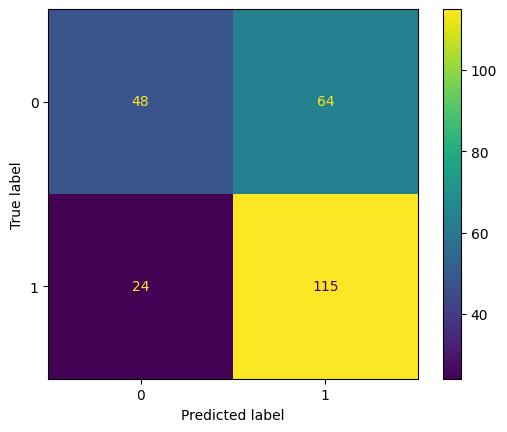

In [102]:
clf = LogisticRegression(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

plot_results(y_test, y_pred, clf)